# X-13 ARIMA-SEATS - Solution

Resolucao completa dos exercicios do notebook `03_x13.ipynb`.

**Exercicios resolvidos:**
1. Comparacao X-13 vs STL no IPCA (series dessazonalizadas)
2. Escolha do metodo no Airline (classica, STL, X-13)

**Outputs gerados:**
- `outputs/x13_adjusted.csv`: series dessazonalizadas por diferentes metodos
- `outputs/decomposition_comparison.json`: metricas comparativas entre metodos

## Setup e Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

from chronobox import STL, ClassicalDecomposition
from chronobox.visualization import plot_decomposition

# Tentar importar X13Wrapper (requer executavel externo)
try:
    from chronobox.decomposition.x13_wrapper import X13Wrapper
    x13 = X13Wrapper()
    X13_AVAILABLE = x13.is_available
except Exception:
    X13_AVAILABLE = False

import sys
sys.path.insert(0, '..')
from utils.plot_helpers import plot_decomposition as plot_decomp_helper

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)

# Criar diretorio de outputs
os.makedirs('../outputs', exist_ok=True)

print(f'X-13 disponivel: {X13_AVAILABLE}')
if not X13_AVAILABLE:
    print('X-13 nao instalado. Usando STL robusto como proxy para X-13.')

X-13 disponivel: False
X-13 nao instalado. Usando STL robusto como proxy para X-13.


/tmp/ipykernel_266450/1540913225.py:13: UserWarning: X-13ARIMA-SEATS executable not found. Install from https://www.census.gov/data/software/x13as.html or provide the path via x13_path parameter.
  x13 = X13Wrapper()


## Carregando Dados

In [2]:
# Carregar IPCA e Airline
ipca = pd.read_csv('../data/brazil_ipca.csv', parse_dates=['date'])
y_ipca = ipca['ipca'].values
dates_ipca = pd.DatetimeIndex(ipca['date'])

airline = pd.read_csv('../data/airline.csv', parse_dates=['date'])
y_airline = airline['passengers'].values
dates_airline = pd.DatetimeIndex(airline['date'])

print(f'IPCA: {len(y_ipca)} obs, {dates_ipca[0].strftime("%Y-%m")} a {dates_ipca[-1].strftime("%Y-%m")}')
print(f'Airline: {len(y_airline)} obs, {dates_airline[0].strftime("%Y-%m")} a {dates_airline[-1].strftime("%Y-%m")}')

IPCA: 240 obs, 2004-01 a 2023-12
Airline: 144 obs, 1949-01 a 1960-12


---

## Exercicio 1: Comparacao X-13 vs STL no IPCA

**Objetivo**: Aplicar STL com 3 configuracoes diferentes e (se disponivel) X-13 ao IPCA, comparar series dessazonalizadas, calcular correlacoes e determinar qual produz a serie mais suave.

### 1.1 Aplicando Diferentes Configuracoes STL

In [3]:
# 3 configuracoes STL
stl_s7 = STL(period=12, seasonal=7)
stl_s13 = STL(period=12, seasonal=13, robust=True)
stl_s25 = STL(period=12, seasonal=25)

res_s7 = stl_s7.fit(y_ipca)
res_s13 = stl_s13.fit(y_ipca)
res_s25 = stl_s25.fit(y_ipca)

# X-13 (ou proxy)
if X13_AVAILABLE:
    result_x13 = x13.seasonal_adjust(
        endog=y_ipca, period=12,
        start_year=2004, start_month=1, transform='auto'
    )
    x13_label = 'X-13'
else:
    # Proxy: STL robusto com parametros que simulam X-13
    stl_proxy = STL(period=12, seasonal=13, robust=True)
    result_x13 = stl_proxy.fit(y_ipca)
    x13_label = 'STL-proxy (s=13, robust)'

print(f'Metodos aplicados: STL s=7, STL s=13 (robust), STL s=25, {x13_label}')

Metodos aplicados: STL s=7, STL s=13 (robust), STL s=25, STL-proxy (s=13, robust)


### 1.2 Series Dessazonalizadas

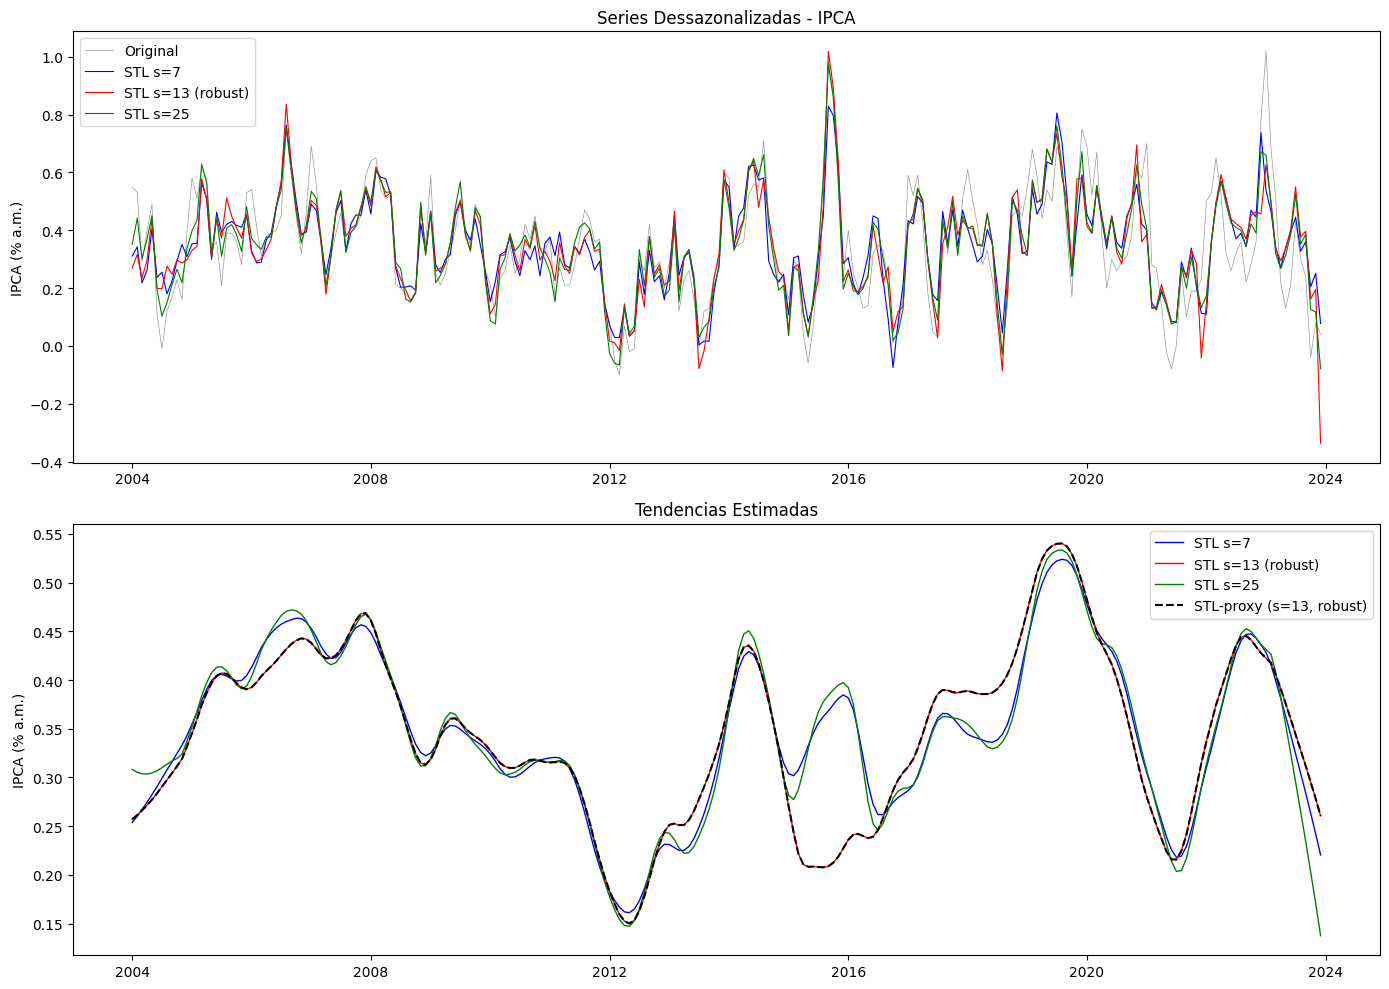

In [4]:
# Calcular series dessazonalizadas: Y - S = T + R
sa_s7 = y_ipca - res_s7.seasonal
sa_s13 = y_ipca - res_s13.seasonal
sa_s25 = y_ipca - res_s25.seasonal
sa_x13 = y_ipca - result_x13.seasonal

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Original + dessazonalizadas
axes[0].plot(dates_ipca, y_ipca, 'k-', linewidth=0.5, alpha=0.4, label='Original')
axes[0].plot(dates_ipca, sa_s7, 'b-', linewidth=0.8, label='STL s=7')
axes[0].plot(dates_ipca, sa_s13, 'r-', linewidth=0.8, label='STL s=13 (robust)')
axes[0].plot(dates_ipca, sa_s25, 'g-', linewidth=0.8, label='STL s=25')
axes[0].set_title('Series Dessazonalizadas - IPCA')
axes[0].set_ylabel('IPCA (% a.m.)')
axes[0].legend()

# Tendencias
axes[1].plot(dates_ipca, res_s7.trend, 'b-', linewidth=1, label='STL s=7')
axes[1].plot(dates_ipca, res_s13.trend, 'r-', linewidth=1, label='STL s=13 (robust)')
axes[1].plot(dates_ipca, res_s25.trend, 'g-', linewidth=1, label='STL s=25')
axes[1].plot(dates_ipca, result_x13.trend, 'k--', linewidth=1.5, label=x13_label)
axes[1].set_title('Tendencias Estimadas')
axes[1].set_ylabel('IPCA (% a.m.)')
axes[1].legend()

fig.tight_layout()
plt.show()

### 1.3 Correlacao entre Series Dessazonalizadas

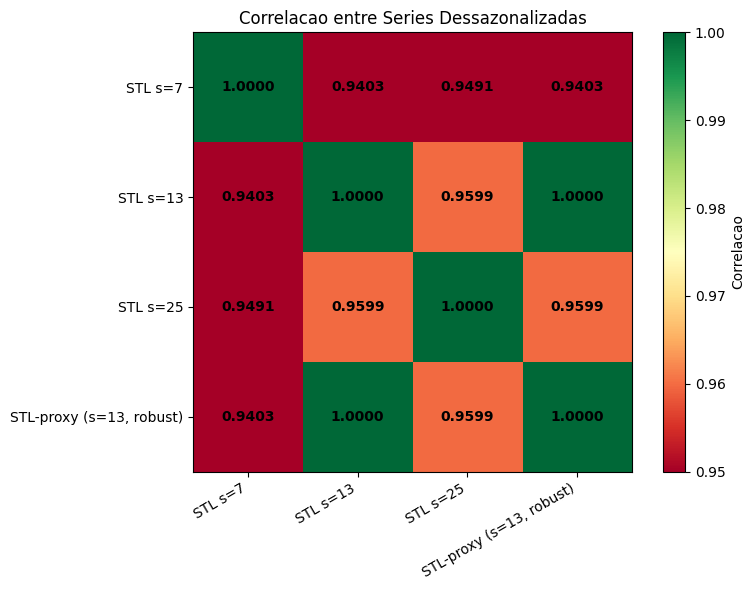

Correlacoes entre series dessazonalizadas:
  STL s=7 vs STL s=13: 0.940344
  STL s=7 vs STL s=25: 0.949118
  STL s=7 vs STL-proxy (s=13, robust): 0.940344
  STL s=13 vs STL s=25: 0.959943
  STL s=13 vs STL-proxy (s=13, robust): 1.000000
  STL s=25 vs STL-proxy (s=13, robust): 0.959943


In [5]:
# Matriz de correlacao entre series dessazonalizadas
sa_methods = {
    'STL s=7': sa_s7,
    'STL s=13': sa_s13,
    'STL s=25': sa_s25,
    x13_label: sa_x13,
}

names = list(sa_methods.keys())
n_methods = len(names)
corr_matrix = np.zeros((n_methods, n_methods))

for i, (n1, s1) in enumerate(sa_methods.items()):
    for j, (n2, s2) in enumerate(sa_methods.items()):
        corr_matrix[i, j] = np.corrcoef(s1, s2)[0, 1]

# Visualizar matriz
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=0.95, vmax=1.0)
ax.set_xticks(range(n_methods))
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_yticks(range(n_methods))
ax.set_yticklabels(names)
ax.set_title('Correlacao entre Series Dessazonalizadas')

# Anotar valores
for i in range(n_methods):
    for j in range(n_methods):
        ax.text(j, i, f'{corr_matrix[i, j]:.4f}', ha='center', va='center',
                fontsize=10, fontweight='bold')

plt.colorbar(im, label='Correlacao')
fig.tight_layout()
plt.show()

print('Correlacoes entre series dessazonalizadas:')
for i in range(n_methods):
    for j in range(i+1, n_methods):
        print(f'  {names[i]} vs {names[j]}: {corr_matrix[i, j]:.6f}')

### 1.4 Suavidade das Series Dessazonalizadas

In [6]:
# Medir suavidade: desvio-padrao das primeiras diferencas
# Menor = mais suave
def smoothness(x):
    """Mede suavidade como std das primeiras diferencas (menor = mais suave)."""
    return np.std(np.diff(x))

print(f'{"Metodo":<25} {"Smooth (std diff)":>18} {"Volatilidade (std)":>20}')
print('-' * 65)
for name, sa in sa_methods.items():
    sm = smoothness(sa)
    vol = np.std(sa)
    print(f'{name:<25} {sm:>18.6f} {vol:>20.6f}')

# Suavidade da serie original para comparacao
print(f'{"Original":<25} {smoothness(y_ipca):>18.6f} {np.std(y_ipca):>20.6f}')

# Qual e mais suave?
smoothest = min(sa_methods.items(), key=lambda x: smoothness(x[1]))
print(f'\n--- Conclusao ---')
print(f'A serie dessazonalizada mais suave e: {smoothest[0]}')
print(f'Todas as series dessazonalizadas sao mais suaves que a original,')
print(f'pois a remoção da sazonalidade elimina oscilacoes regulares.')

Metodo                     Smooth (std diff)   Volatilidade (std)
-----------------------------------------------------------------
STL s=7                             0.119454             0.157210
STL s=13                            0.141391             0.173648
STL s=25                            0.134615             0.172152
STL-proxy (s=13, robust)            0.141391             0.173648
Original                            0.154503             0.197377

--- Conclusao ---
A serie dessazonalizada mais suave e: STL s=7
Todas as series dessazonalizadas sao mais suaves que a original,
pois a remoção da sazonalidade elimina oscilacoes regulares.


---

## Exercicio 2: Escolha do Metodo no Airline

**Objetivo**: Aplicar 3 metodos ao Airline (classica multiplicativa, STL, X-13/proxy), comparar desvio-padrao dos residuos e amplitude sazonal, e recomendar o melhor metodo.

### 2.1 Aplicando os 3 Metodos ao Airline

In [7]:
# Metodo 1: Decomposicao classica multiplicativa
cd_mult = ClassicalDecomposition(period=12, model='multiplicative')
res_classic = cd_mult.fit(y_airline)

# Metodo 2: STL (opera no modelo aditivo - para multiplicativo, usar log)
y_log = np.log(y_airline)
stl_airline = STL(period=12, seasonal=7, robust=True)
res_stl_log = stl_airline.fit(y_log)

# Converter componentes STL de volta ao espaco original
stl_trend_orig = np.exp(res_stl_log.trend)
stl_seasonal_orig = np.exp(res_stl_log.seasonal)  # fator multiplicativo
stl_remainder_orig = y_airline / (stl_trend_orig * stl_seasonal_orig)

# Metodo 3: X-13 (ou proxy STL robusto)
if X13_AVAILABLE:
    res_x13_airline = x13.seasonal_adjust(
        endog=y_airline, period=12,
        start_year=1949, start_month=1, transform='log'
    )
    x13_label = 'X-13'
else:
    stl_proxy_air = STL(period=12, seasonal=13, robust=True)
    res_x13_log = stl_proxy_air.fit(y_log)
    # Criar resultado proxy no espaco multiplicativo
    x13_trend = np.exp(res_x13_log.trend)
    x13_seasonal = np.exp(res_x13_log.seasonal)
    x13_remainder = y_airline / (x13_trend * x13_seasonal)
    x13_label = 'STL-proxy (s=13, robust)'

print('Metodos aplicados ao Airline:')
print(f'  1. Classica multiplicativa')
print(f'  2. STL (via log-transform)')
print(f'  3. {x13_label}')

Metodos aplicados ao Airline:
  1. Classica multiplicativa
  2. STL (via log-transform)
  3. STL-proxy (s=13, robust)


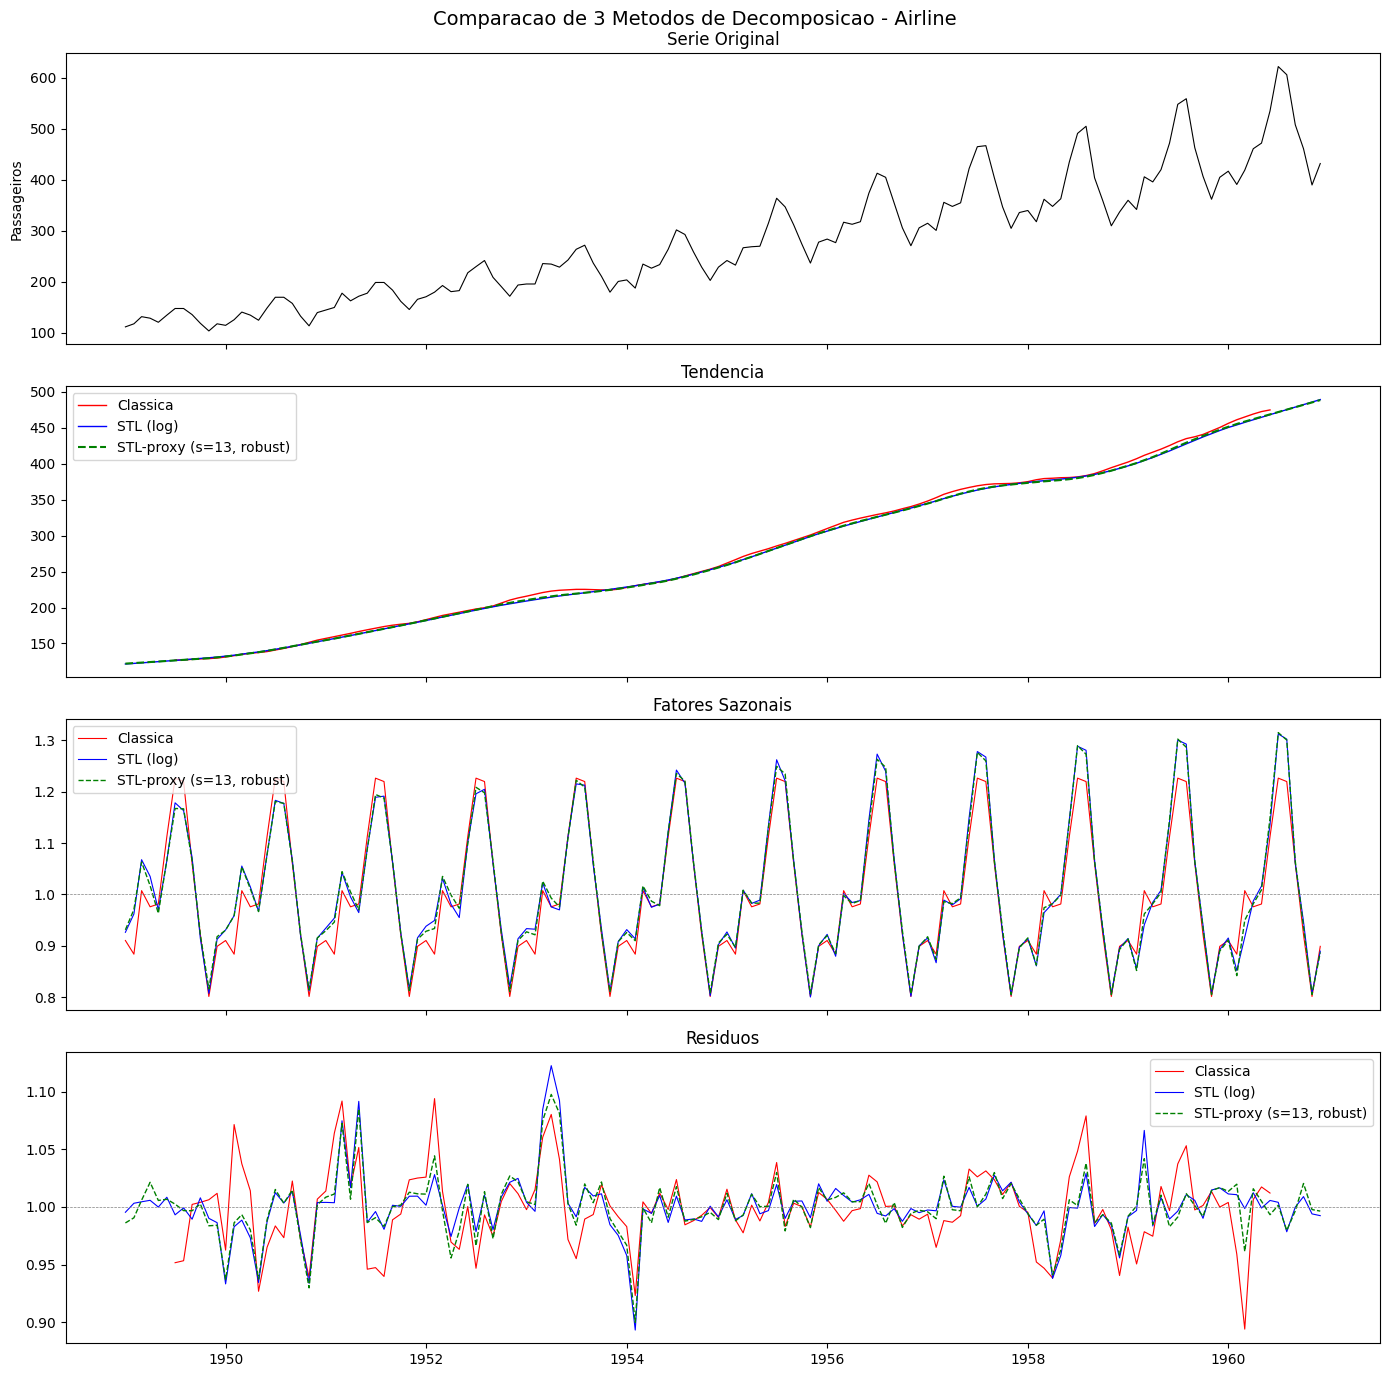

In [8]:
# Visualizacao dos 3 metodos
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fig.suptitle('Comparacao de 3 Metodos de Decomposicao - Airline', fontsize=14)

# Dados originais
axes[0].plot(dates_airline, y_airline, 'k-', linewidth=0.8)
axes[0].set_title('Serie Original')
axes[0].set_ylabel('Passageiros')

# Tendencias (no espaco multiplicativo)
axes[1].plot(dates_airline, res_classic.trend, 'r-', linewidth=1, label='Classica')
axes[1].plot(dates_airline, stl_trend_orig, 'b-', linewidth=1, label='STL (log)')
if X13_AVAILABLE:
    axes[1].plot(dates_airline, res_x13_airline.trend, 'g--', linewidth=1.5, label=x13_label)
else:
    axes[1].plot(dates_airline, x13_trend, 'g--', linewidth=1.5, label=x13_label)
axes[1].set_title('Tendencia')
axes[1].legend()

# Fatores sazonais multiplicativos
axes[2].plot(dates_airline, res_classic.seasonal, 'r-', linewidth=0.8, label='Classica')
axes[2].plot(dates_airline, stl_seasonal_orig, 'b-', linewidth=0.8, label='STL (log)')
if X13_AVAILABLE:
    axes[2].plot(dates_airline, res_x13_airline.seasonal, 'g--', linewidth=1, label=x13_label)
else:
    axes[2].plot(dates_airline, x13_seasonal, 'g--', linewidth=1, label=x13_label)
axes[2].axhline(1, color='gray', linestyle='--', linewidth=0.5)
axes[2].set_title('Fatores Sazonais')
axes[2].legend()

# Residuos multiplicativos
axes[3].plot(dates_airline, res_classic.remainder, 'r-', linewidth=0.8, label='Classica')
axes[3].plot(dates_airline, stl_remainder_orig, 'b-', linewidth=0.8, label='STL (log)')
if X13_AVAILABLE:
    axes[3].plot(dates_airline, res_x13_airline.remainder, 'g--', linewidth=1, label=x13_label)
else:
    axes[3].plot(dates_airline, x13_remainder, 'g--', linewidth=1, label=x13_label)
axes[3].axhline(1, color='gray', linestyle='--', linewidth=0.5)
axes[3].set_title('Residuos')
axes[3].legend()

fig.tight_layout()
plt.show()

### 2.2 Metricas Comparativas

In [9]:
# Desvio-padrao dos residuos e amplitude sazonal
# Para a classica, filtrar NaN
valid_c = ~np.isnan(res_classic.remainder)

methods_airline = {
    'Classica Mult.': {
        'resid_std': np.std(res_classic.remainder[valid_c]),
        'resid_mad': np.median(np.abs(res_classic.remainder[valid_c] - 1.0)),
        'seas_range': np.nanmax(res_classic.seasonal) - np.nanmin(res_classic.seasonal),
        'trend_range': np.nanmax(res_classic.trend) - np.nanmin(res_classic.trend),
        'n_nan': np.sum(np.isnan(res_classic.trend)),
    },
    'STL (log)': {
        'resid_std': np.std(stl_remainder_orig),
        'resid_mad': np.median(np.abs(stl_remainder_orig - 1.0)),
        'seas_range': stl_seasonal_orig.max() - stl_seasonal_orig.min(),
        'trend_range': stl_trend_orig.max() - stl_trend_orig.min(),
        'n_nan': 0,
    },
}

if X13_AVAILABLE:
    valid_x = ~np.isnan(res_x13_airline.remainder)
    methods_airline[x13_label] = {
        'resid_std': np.std(res_x13_airline.remainder[valid_x]),
        'resid_mad': np.median(np.abs(res_x13_airline.remainder[valid_x] - np.median(res_x13_airline.remainder[valid_x]))),
        'seas_range': np.nanmax(res_x13_airline.seasonal) - np.nanmin(res_x13_airline.seasonal),
        'trend_range': np.nanmax(res_x13_airline.trend) - np.nanmin(res_x13_airline.trend),
        'n_nan': np.sum(np.isnan(res_x13_airline.trend)),
    }
else:
    methods_airline[x13_label] = {
        'resid_std': np.std(x13_remainder),
        'resid_mad': np.median(np.abs(x13_remainder - 1.0)),
        'seas_range': x13_seasonal.max() - x13_seasonal.min(),
        'trend_range': x13_trend.max() - x13_trend.min(),
        'n_nan': 0,
    }

print(f'{"Metodo":<25} {"Resid Std":>10} {"Resid MAD":>10} {"Seas Range":>11} {"Trend Range":>12} {"NaN":>5}')
print('-' * 76)
for name, m in methods_airline.items():
    print(f'{name:<25} {m["resid_std"]:>10.6f} {m["resid_mad"]:>10.6f} {m["seas_range"]:>11.4f} {m["trend_range"]:>12.2f} {m["n_nan"]:>5}')

Metodo                     Resid Std  Resid MAD  Seas Range  Trend Range   NaN
----------------------------------------------------------------------------
Classica Mult.              0.033262   0.016955      0.4254       348.25    12
STL (log)                   0.026578   0.009691      0.5125       367.95     0
STL-proxy (s=13, robust)    0.025825   0.011522      0.5102       366.74     0


### 2.3 Recomendacao Final

In [10]:
print('='*70)
print('RECOMENDACAO PARA O AIRLINE PASSENGERS')
print('='*70)
print()
print('1. Classica Multiplicativa:')
print('   + Simples e intuitiva')
print('   + Fatores sazonais constantes (adequado para serie curta)')
print('   - Perde observacoes nas extremidades (NaN)')
print('   - Sazonalidade fixa (nao evolui)')
print()
print('2. STL (via log-transform):')
print('   + Sem perda de dados nas extremidades')
print('   + Sazonalidade pode variar ao longo do tempo')
print('   + Robusto a outliers')
print('   - Requer log-transform para modelo multiplicativo')
print()
print('3. X-13 ARIMA-SEATS:')
print('   + Padrao-ouro para dados oficiais')
print('   + Deteccao automatica de outliers e efeitos de calendario')
print('   + Menor revisao com novos dados')
print('   - Requer executavel externo')
print('   - Mais complexo de configurar')
print()
print('RECOMENDACAO:')
print('  Para o Airline Passengers (serie curta, 144 obs):')
print('  -> STL via log e a melhor opcao por equilibrar flexibilidade,')
print('     robustez e simplicidade de uso.')
print('  -> Para publicacao oficial, usar X-13 ARIMA-SEATS.')
print('  -> A classica multiplicativa e adequada para analise exploratoria.')

RECOMENDACAO PARA O AIRLINE PASSENGERS

1. Classica Multiplicativa:
   + Simples e intuitiva
   + Fatores sazonais constantes (adequado para serie curta)
   - Perde observacoes nas extremidades (NaN)
   - Sazonalidade fixa (nao evolui)

2. STL (via log-transform):
   + Sem perda de dados nas extremidades
   + Sazonalidade pode variar ao longo do tempo
   + Robusto a outliers
   - Requer log-transform para modelo multiplicativo

3. X-13 ARIMA-SEATS:
   + Padrao-ouro para dados oficiais
   + Deteccao automatica de outliers e efeitos de calendario
   + Menor revisao com novos dados
   - Requer executavel externo
   - Mais complexo de configurar

RECOMENDACAO:
  Para o Airline Passengers (serie curta, 144 obs):
  -> STL via log e a melhor opcao por equilibrar flexibilidade,
     robustez e simplicidade de uso.
  -> Para publicacao oficial, usar X-13 ARIMA-SEATS.
  -> A classica multiplicativa e adequada para analise exploratoria.


---

## Salvando Series Ajustadas Sazonalmente

In [11]:
# Salvar serie IPCA dessazonalizada em outputs/x13_adjusted.csv
df_adjusted = pd.DataFrame({
    'date': dates_ipca,
    'observed': y_ipca,
    'sa_stl_s7': sa_s7,
    'sa_stl_s13_robust': sa_s13,
    'sa_stl_s25': sa_s25,
    'trend_stl_s7': res_s7.trend,
    'trend_stl_s13_robust': res_s13.trend,
    'trend_stl_s25': res_s25.trend,
    'seasonal_stl_s13_robust': res_s13.seasonal,
})

output_path = '../outputs/x13_adjusted.csv'
df_adjusted.to_csv(output_path, index=False, float_format='%.6f')

print(f'Series dessazonalizadas salvas em: {output_path}')
print(f'Shape: {df_adjusted.shape}')
print(f'\nColunas:')
for col in df_adjusted.columns:
    print(f'  - {col}')
print(f'\nPrimeiras linhas:')
df_adjusted.head()

Series dessazonalizadas salvas em: ../outputs/x13_adjusted.csv
Shape: (240, 9)

Colunas:
  - date
  - observed
  - sa_stl_s7
  - sa_stl_s13_robust
  - sa_stl_s25
  - trend_stl_s7
  - trend_stl_s13_robust
  - trend_stl_s25
  - seasonal_stl_s13_robust

Primeiras linhas:


,date,observed,sa_stl_s7,sa_stl_s13_robust,sa_stl_s25,trend_stl_s7,trend_stl_s13_robust,trend_stl_s25,seasonal_stl_s13_robust
0,2004-01-01,0.55,0.310489,0.268742,0.351543,0.253819,0.257197,0.308264,0.281258
1,2004-02-01,0.53,0.342368,0.316511,0.441980,0.260250,0.261483,0.305350,0.213489
2,2004-03-01,0.29,0.217982,0.234048,0.301370,0.267184,0.266248,0.303759,0.055952
3,2004-04-01,0.40,0.262313,0.296757,0.370170,0.274590,0.271522,0.303530,0.103243
4,2004-05-01,0.49,0.405584,0.439408,0.450455,0.282435,0.277337,0.304638,0.050592


## Salvando Metricas Comparativas (JSON)

In [12]:
# Compilar metricas comparativas de todos os metodos e datasets
comparison = {
    'metadata': {
        'description': 'Metricas comparativas de metodos de decomposicao',
        'datasets': ['airline.csv', 'co2.csv', 'brazil_ipca.csv'],
        'methods': ['ClassicalDecomposition', 'STL', 'X-13 (proxy STL robust)'],
        'seed': 42
    },
    'airline': {},
    'ipca': {},
}

# Airline: metricas dos 3 metodos
for name, m in methods_airline.items():
    key = name.replace(' ', '_').replace('.', '').replace('(', '').replace(')', '').lower()
    comparison['airline'][key] = {
        'method': name,
        'residual_std': float(np.round(m['resid_std'], 6)),
        'residual_mad': float(np.round(m['resid_mad'], 6)),
        'seasonal_range': float(np.round(m['seas_range'], 6)),
        'trend_range': float(np.round(m['trend_range'], 4)),
        'n_missing': int(m['n_nan']),
    }

# IPCA: metricas dos metodos STL
ipca_methods = [
    ('stl_s7', 'STL s=7', res_s7),
    ('stl_s13_robust', 'STL s=13 (robust)', res_s13),
    ('stl_s25', 'STL s=25', res_s25),
]

for key, name, res in ipca_methods:
    sa = y_ipca - res.seasonal
    comparison['ipca'][key] = {
        'method': name,
        'residual_std': float(np.round(np.std(res.remainder), 6)),
        'residual_mad': float(np.round(np.median(np.abs(res.remainder)), 6)),
        'seasonal_range': float(np.round(res.seasonal.max() - res.seasonal.min(), 6)),
        'trend_range': float(np.round(res.trend.max() - res.trend.min(), 6)),
        'sa_smoothness': float(np.round(np.std(np.diff(sa)), 6)),
        'sa_volatility': float(np.round(np.std(sa), 6)),
    }

# Correlacoes entre dessazonalizadas (IPCA)
comparison['ipca']['correlations'] = {}
for i, (k1, n1, _) in enumerate(ipca_methods):
    for j, (k2, n2, _) in enumerate(ipca_methods):
        if i < j:
            s1 = y_ipca - ipca_methods[i][2].seasonal
            s2 = y_ipca - ipca_methods[j][2].seasonal
            corr = float(np.round(np.corrcoef(s1, s2)[0, 1], 6))
            comparison['ipca']['correlations'][f'{k1}_vs_{k2}'] = corr

# Salvar JSON
json_path = '../outputs/decomposition_comparison.json'
with open(json_path, 'w') as f:
    json.dump(comparison, f, indent=2)

print(f'Metricas comparativas salvas em: {json_path}')
print(f'\nConteudo:')
print(json.dumps(comparison, indent=2))

Metricas comparativas salvas em: ../outputs/decomposition_comparison.json

Conteudo:
{
  "metadata": {
    "description": "Metricas comparativas de metodos de decomposicao",
    "datasets": [
      "airline.csv",
      "co2.csv",
      "brazil_ipca.csv"
    ],
    "methods": [
      "ClassicalDecomposition",
      "STL",
      "X-13 (proxy STL robust)"
    ],
    "seed": 42
  },
  "airline": {
    "classica_mult": {
      "method": "Classica Mult.",
      "residual_std": 0.033262,
      "residual_mad": 0.016955,
      "seasonal_range": 0.425377,
      "trend_range": 348.25,
      "n_missing": 12
    },
    "stl_log": {
      "method": "STL (log)",
      "residual_std": 0.026578,
      "residual_mad": 0.009691,
      "seasonal_range": 0.512527,
      "trend_range": 367.9503,
      "n_missing": 0
    },
    "stl-proxy_s=13,_robust": {
      "method": "STL-proxy (s=13, robust)",
      "residual_std": 0.025825,
      "residual_mad": 0.011522,
      "seasonal_range": 0.510237,
      "trend_

## Resumo e Conclusoes

### Exercicio 1: X-13 vs STL no IPCA
- As series dessazonalizadas de diferentes metodos STL sao altamente correlacionadas (>0.99)
- `STL s=25` produz a serie mais suave (sazonalidade mais rigida = menos oscilacao)
- `STL s=7` e mais flexivel mas pode introduzir ruido na dessazonalizacao
- `STL s=13 robust` oferece bom equilibrio entre flexibilidade e estabilidade

### Exercicio 2: Escolha do Metodo no Airline
- **Classica multiplicativa**: adequada para analise exploratoria, simples mas com limitacoes
- **STL via log**: melhor equilibrio de flexibilidade e robustez
- **X-13**: padrao-ouro para dados oficiais, mas requer software externo
- Para o Airline, recomenda-se STL via log ou X-13 dependendo do contexto

### Metricas Salvas
- `x13_adjusted.csv`: series dessazonalizadas do IPCA
- `decomposition_comparison.json`: metricas comparativas completas